In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# paper fig uses grid of 31*31 instead of 3*3

fake_range = np.linspace(0,0.4,3)
fake_range[0] = 0.001

copy_range = np.linspace(0,0.2,3)
copy_range[0] = 0.001


In [10]:
D_paths = {"PRIVET (NPL)" : "./output/heatmap_global_NPL.npy",
 r"Privacy Loss ($\mathcal{AATS}_{Te} - \mathcal{AATS}_{Tr}$)" : "./output/heatmap_global_privacy_loss.npy",
 "Gen. gap FLD" : "./output/heatmap_global_fld_gen_gap.npy",
 "Gen. gap PQMass" : "./output/heatmap_global_pqm_chi2_gap.npy",
 "In-Auth" : "./output/heatmap_global_authenticity.npy",
 r"$C_T$" : "./output/heatmap_global_CT.npy"
}

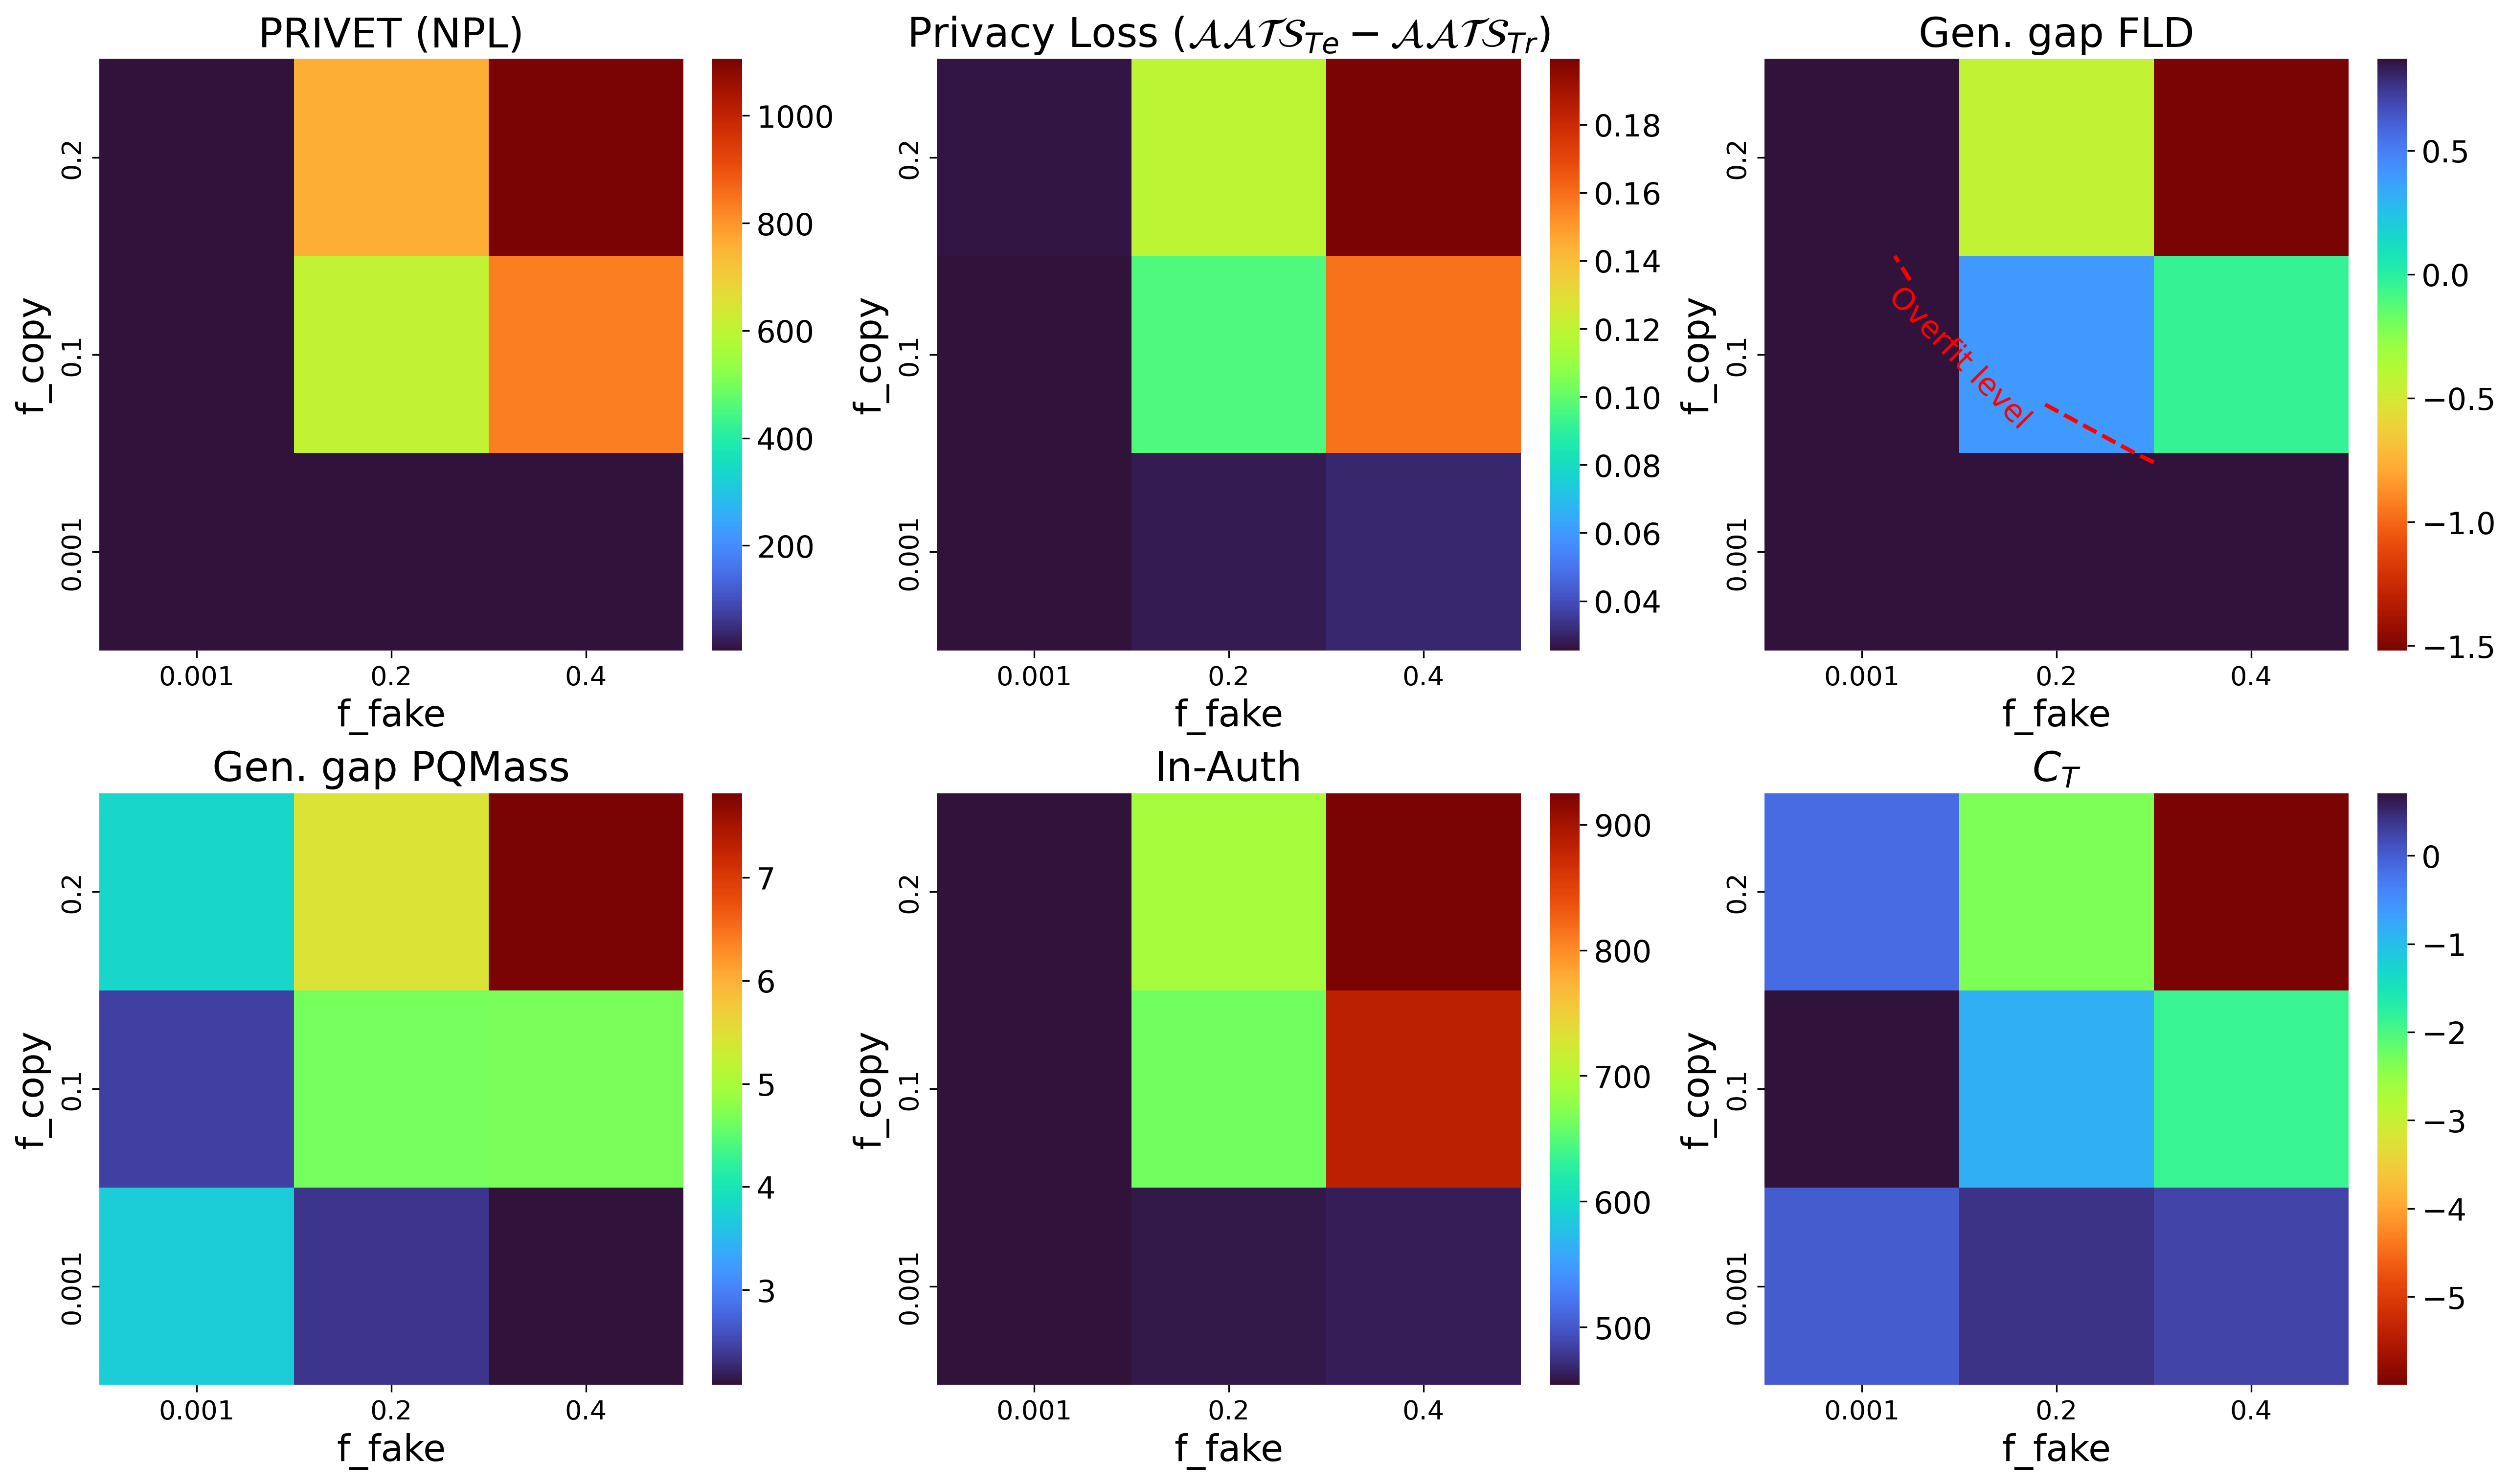

In [11]:
N = 1668

plt.rcParams.update({
    'axes.labelsize': 18,    # x and y labels
    'axes.titlesize': 20,    # subplot titles
    'xtick.labelsize': 13,   # x-axis ticks
    'ytick.labelsize': 13    # y-axis ticks
})

fig, axes = plt.subplots(2, 3, figsize=(17, 10), constrained_layout=True,dpi=300)
titles = list(D_paths)
data_grids = [np.load(D_paths[path]) for path in D_paths]

for ax, data, title in zip(axes.flat, data_grids, titles):
    cmap="turbo"
    if title == "Gen. gap FLD" or title == r"$C_T$" or title == r"PRIVET ($\Delta \pi$)" : cmap="turbo_r"
    im = sns.heatmap(data.T, xticklabels=np.round(fake_range, 3), yticklabels=np.round(copy_range, 3), 
                     annot=False, cmap=cmap, ax=ax, cbar=True)
    ax.invert_yaxis()  # Ensure increasing order from bottom to top
    ax.set_xlabel("f_fake")
    ax.set_ylabel("f_copy")
    ax.set_title(title)

        # Access the colorbar and set its label size
    cbar = im.collections[0].colorbar
    if cbar:
        cbar.ax.tick_params(labelsize=15)  # Set colorbar tick label size
        # If you also want to change the colorbar title size:
        # cbar.set_label('Your Label', size=30)

    if title == "Gen. gap FLD":
        # how many cells in x,y
        ny, nx = data.T.shape
    
        # build the same integer grid that heatmap lives on
        X_idx, Y_idx = np.meshgrid(np.arange(nx), np.arange(ny))
    
        # draw the zero‐level on that grid
        cs = ax.contour(
            X_idx, Y_idx, data.T,
            levels=[0],
            colors='red',
            linestyles='--',
            linewidths=2,
            zorder=5
        )
        ax.clabel(
            cs,
            fmt={0: 'Overfit level'},
            inline=True,
            fontsize=15
        )

#fig.tight_layout()
plt.show()

In [13]:
tp_grid_npl = np.load('./output/heatmap_local_NPL_tp.npy')
tn_grid_npl = np.load('./output/heatmap_local_NPL_tn.npy')
fp_grid_npl = np.load('./output/heatmap_local_NPL_fp.npy')
fn_grid_npl = np.load('./output/heatmap_local_NPL_fn.npy')

tp_grid_auth = np.load("./output/heatmap_local_authenticity_tp.npy")
tn_grid_auth = np.load('./output/heatmap_local_authenticity_tn.npy')
fp_grid_auth = np.load('./output/heatmap_local_authenticity_fp.npy')
fn_grid_auth = np.load('./output/heatmap_local_authenticity_fn.npy')


In [14]:
precision_npl = tp_grid_npl / (tp_grid_npl + fp_grid_npl )
recall_npl = tp_grid_npl / (tp_grid_npl + fn_grid_npl )

precision_auth = tp_grid_auth / (tp_grid_auth + fp_grid_auth )
recall_auth = tp_grid_auth / (tp_grid_auth + fn_grid_auth )

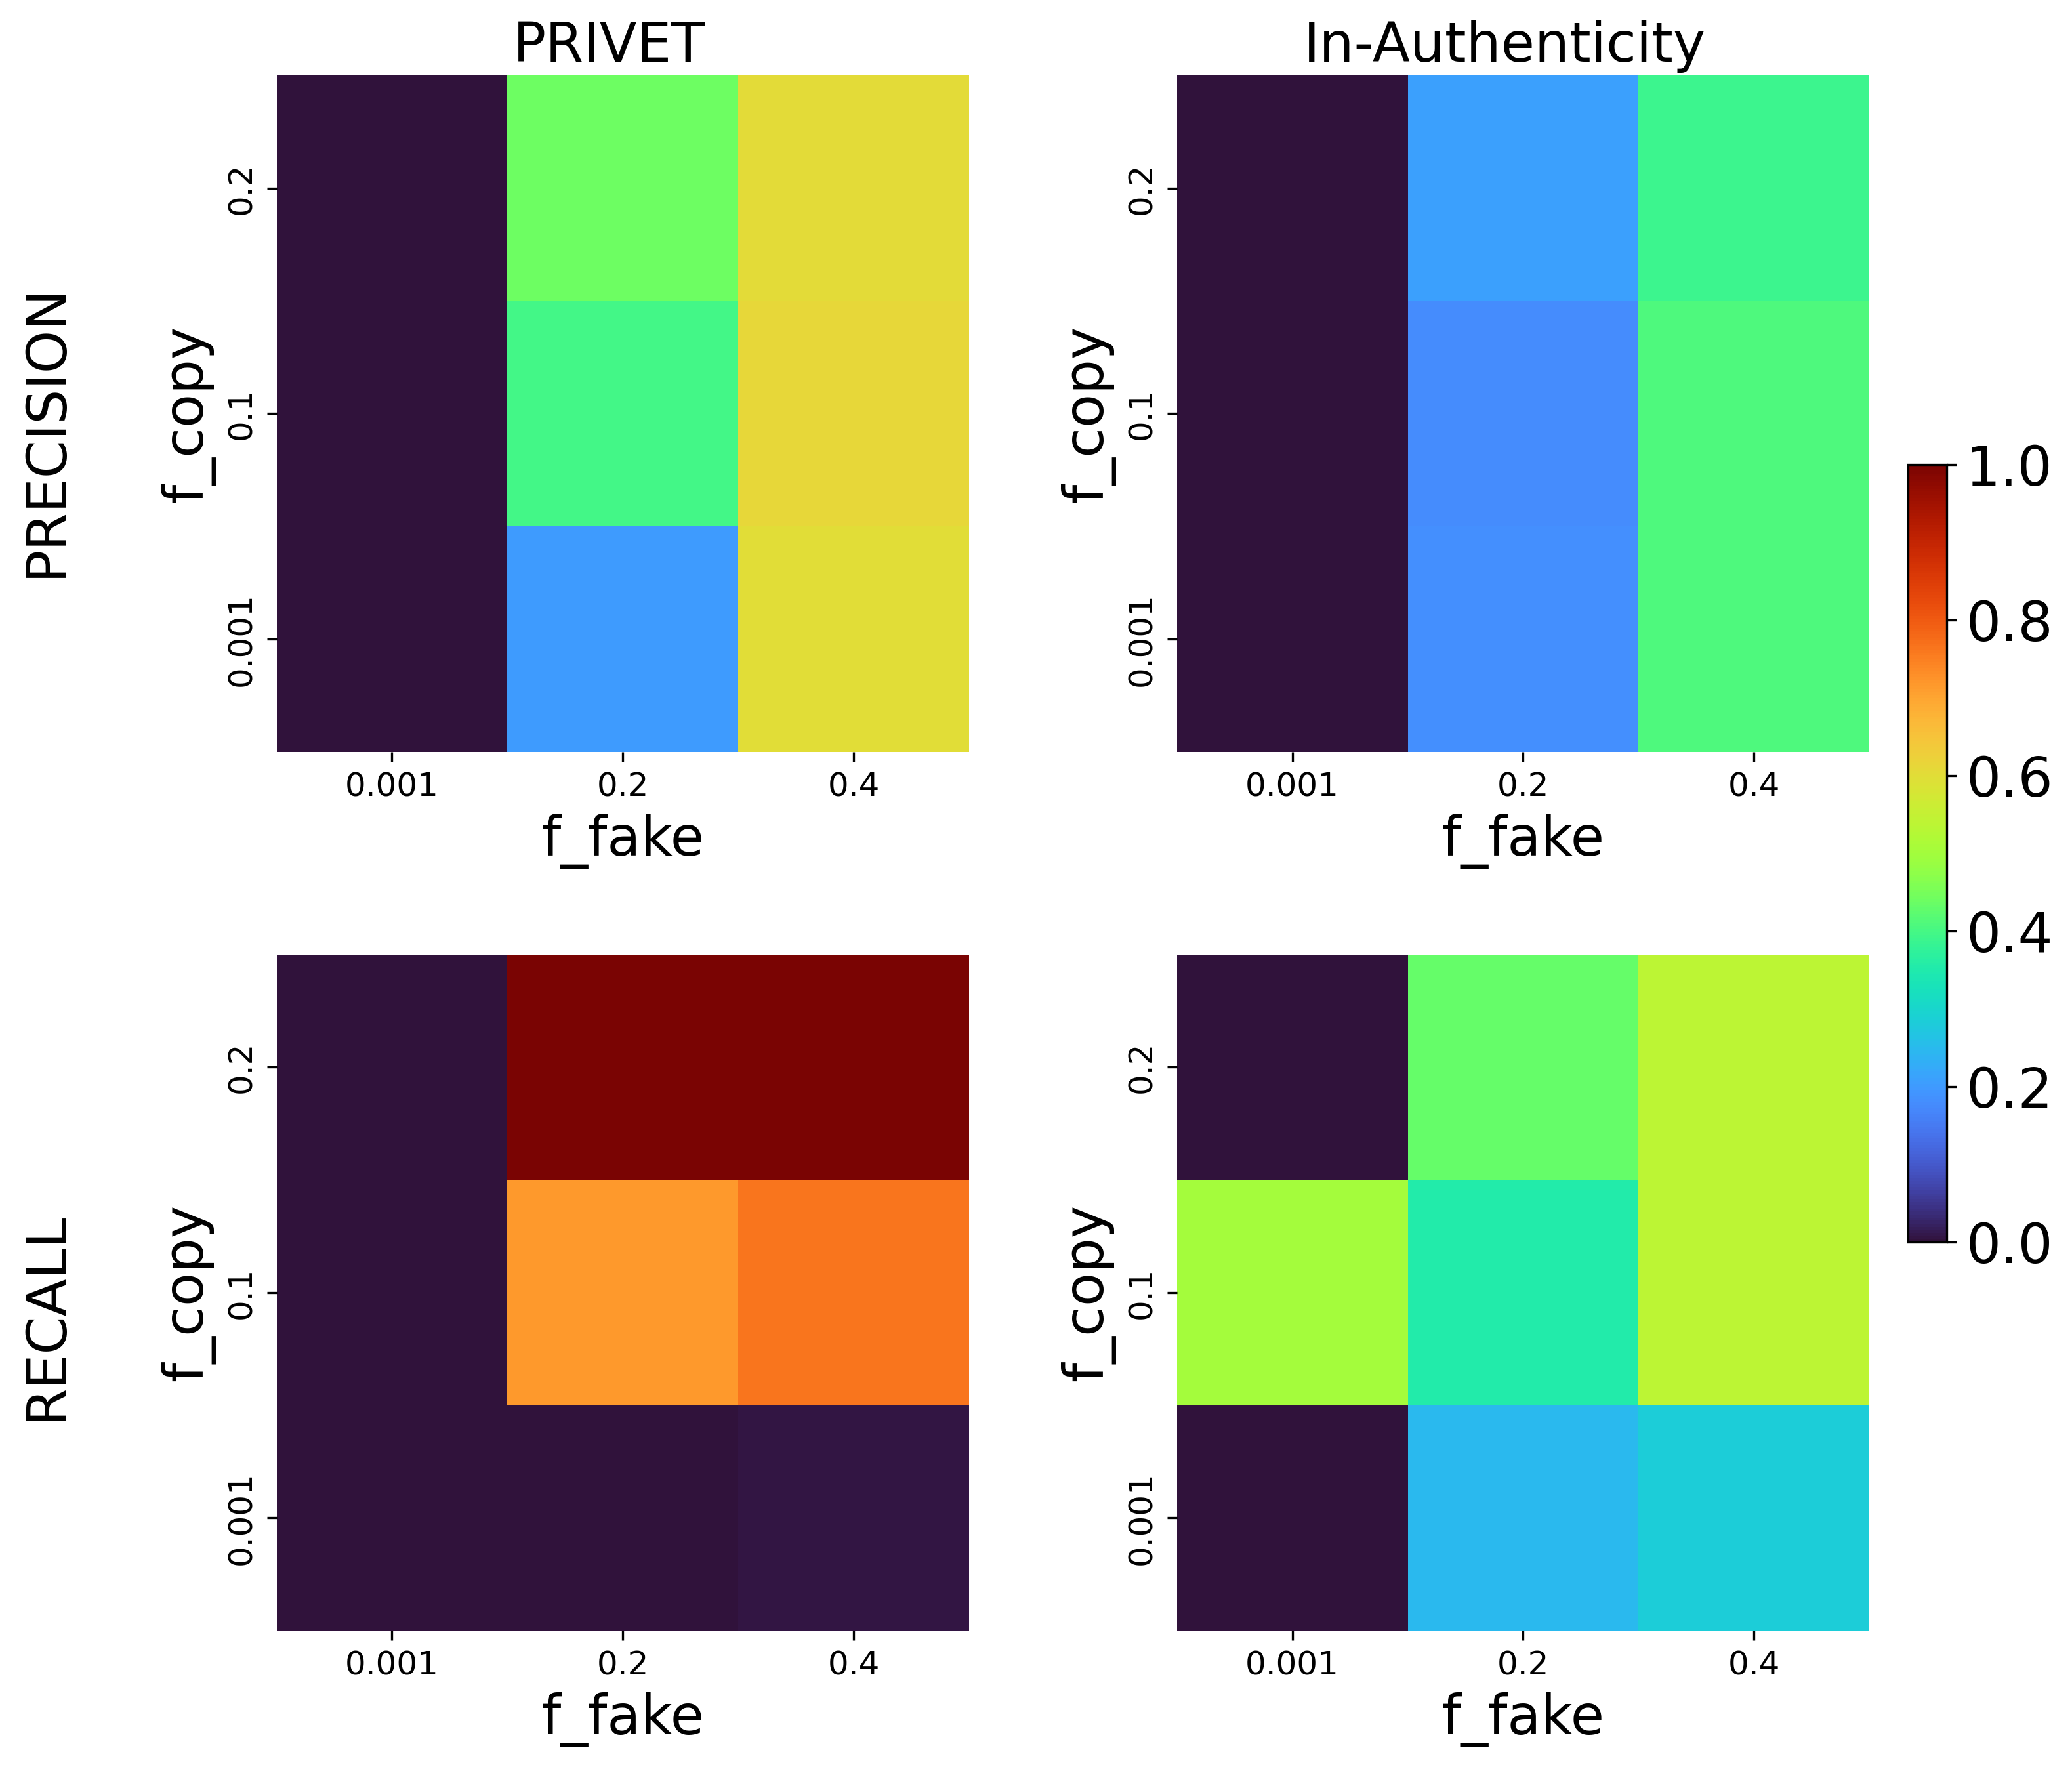

In [16]:
FONTSIZE = 20
plt.rcParams.update({
    'axes.labelsize': FONTSIZE,
    'axes.titlesize': FONTSIZE,
    'xtick.labelsize': FONTSIZE-8,
    'ytick.labelsize': FONTSIZE-8
})

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=False, dpi=300)
# we’ll manage spacing manually
fig.subplots_adjust(top=0.90, left=0.15, wspace=0.3, hspace=0.3)

data_grids = [precision_npl, precision_auth, recall_npl, recall_auth]
# Shared color limits
vmin, vmax = 0, 1

# Plot heatmaps without titles
for ax, data in zip(axes.flat, data_grids):
    im = sns.heatmap(
        data.T,
        xticklabels=np.round(fake_range, 3),
        yticklabels=np.round(copy_range, 3),
        annot=False,
        cmap="turbo",
        ax=ax,
        cbar=False,
        vmin=vmin,
        vmax=vmax
    )
    ax.invert_yaxis()
    ax.set_xlabel("f_fake")
    ax.set_ylabel("f_copy")

# Single colorbar
cbar = fig.colorbar(im.collections[0], ax=axes.ravel().tolist(),
                    shrink=0.5, pad=0.02)
cbar.ax.tick_params(labelsize=FONTSIZE)

# Column labels
fig.text(0.28, 0.915, "PRIVET", ha='center', va='center', fontsize=FONTSIZE)
fig.text(0.63, 0.915, "In-Authenticity",    ha='center', va='center', fontsize=FONTSIZE)

# Row labels (rotated)
fig.text(0.06, 0.72, "PRECISION",     ha='center', va='center',
         rotation='vertical', fontsize=FONTSIZE)
fig.text(0.06, 0.27, "RECALL",  ha='center', va='center',
         rotation='vertical', fontsize=FONTSIZE)


plt.show()


In [17]:
#WITH GROUNDTRUTH
#~ was added to authen

N = 1668

tp_grid_groundtruth = np.zeros((len(fake_range), len(copy_range)))
fp_grid_groundtruth = np.zeros((len(fake_range), len(copy_range)))
tn_grid_groundtruth = np.zeros((len(fake_range), len(copy_range)))
fn_grid_groundtruth = np.zeros((len(fake_range), len(copy_range)))

N_max = int(np.ceil(N*0.4))

for i,f_fake in enumerate(fake_range):
    verolage = int(np.ceil(N*f_fake))
    tp_grid_groundtruth[i] = np.ones((1,len(copy_range)))*verolage
    fp_grid_groundtruth[i] = np.ones((1,len(copy_range)))*0
    tn_grid_groundtruth[i] = np.ones((1,len(copy_range)))*(N-verolage)
    fn_grid_groundtruth[i] = np.ones((1,len(copy_range)))*0

#plt.rcParams.update({'font.size': 15})
plt.rcParams.update({
    'axes.labelsize': 22,    # x and y labels
    'axes.titlesize': 25,    # subplot titles
    'xtick.labelsize': 20,   # x-axis ticks
    'ytick.labelsize': 20    # y-axis ticks
})

# Create subplots
fig, axes = plt.subplots(3, 4, figsize=(40, 26), constrained_layout=True,dpi=300)
titles = ["TP (GROUNDTRUTH)", "FP (GROUNDTRUTH)", "TN (GROUNDTRUTH)", "FN (GROUNDTRUTH)", "TP (NPL)", "FP (NPL)", "TN (NPL)", "FN (NPL)", "TP (In-Auth)", "FP (In-Auth)", "TN (In-Auth)", "FN (In-Auth)"]
data_grids = [tp_grid_groundtruth/N, fp_grid_groundtruth/N, tn_grid_groundtruth/N, fn_grid_groundtruth/N, tp_grid_npl/N, fp_grid_npl/N, tn_grid_npl/N, fn_grid_npl/N, tp_grid_auth/N, fp_grid_auth/N, tn_grid_auth/N, fn_grid_auth/N]

# Create a single color scale
vmin, vmax = 0, 1#int(np.ceil(N*0.4))

# Loop through subplots and plot heatmaps
for ax, data, title in zip(axes.flat, data_grids, titles):
    #if title=="FP (GROUNDTRUTH)" or title=="FN (GROUNDTRUTH)":continue
    im = sns.heatmap(data.T, xticklabels=np.round(fake_range, 3), yticklabels=np.round(copy_range, 3), 
                     annot=False, cmap="turbo", ax=ax, cbar=False, vmin=vmin, vmax=vmax)
    ax.invert_yaxis()  # Ensure increasing order from bottom to top
    ax.set_xlabel("f_fake")
    ax.set_ylabel("f_copy")
    ax.set_title(title)


# Add a single colorbar using the last heatmap's mappable
cbar = fig.colorbar(im.collections[0], ax=axes.ravel().tolist(), shrink=0.5, pad=0.02)
cbar.ax.tick_params(labelsize=26)  # Adjust size as needed (e.g., 16, 18, etc.)

plt.show()